In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Set global parameters
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device("cpu")
print(f"Using device: {device}")

# Define network parameters
train_size, val_size, test_size = 120, 60, 20
size = train_size + val_size + test_size
print(f"Overall sample size: {size}, train/val/test ratio: {train_size/size:.2f}/{val_size/size:.2f}/{test_size/size:.2f}")
learning_rate = 1e-5
hidden_size = 128
batch_size = 20
epoch_amount = 1000

# Define the function and its domain
a, b = -3, 3

def f(x) -> np.ndarray:
    return np.exp(x**2) * np.cos(10*x)

Using device: mps
Overall sample size: 200, train/val/test ratio: 0.60/0.30/0.10


### Visualization of function

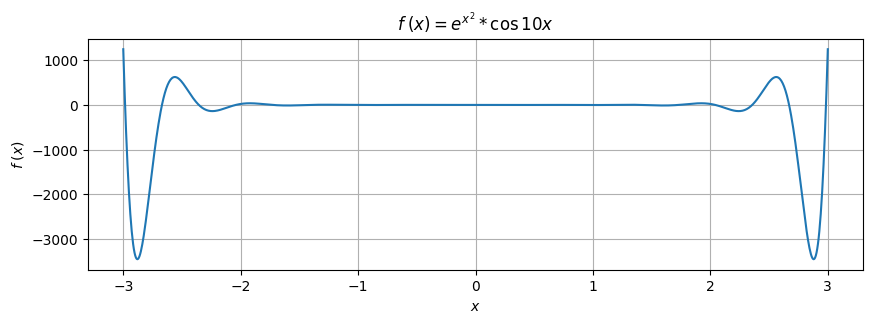

In [2]:
x = np.linspace(a, b, 1000)
y = f(x)

plt.figure(figsize=(10, 3))
plt.plot(x, y)
plt.title(r"$f\;(x) = e^{x^2} * \cos{10x}$")
plt.xlabel(r"$x$")
plt.ylabel(r"$f\;(x)$")
plt.grid(True)
plt.show()

### Generating and visualizing data

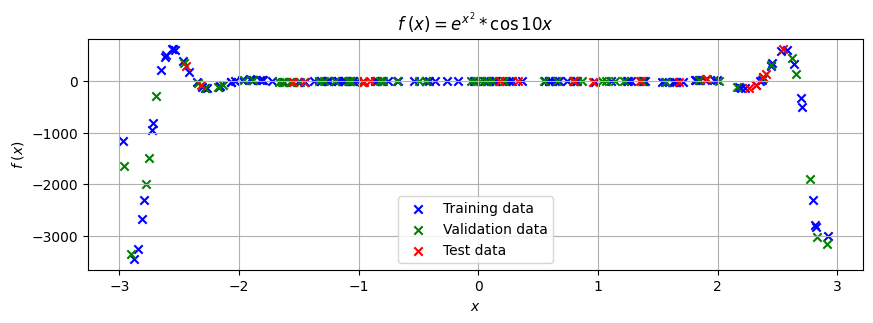

In [3]:
train_x = np.random.uniform(a, b, train_size)
train_y = f(train_x)

val_x = np.random.uniform(a, b, val_size)
val_y = f(val_x)

test_x = np.random.uniform(a, b, test_size)
test_y = f(test_x)

plt.figure(figsize=(10, 3))
plt.scatter(train_x, train_y, label="Training data", marker="x", color="blue")
plt.scatter(val_x, val_y, label="Validation data", marker="x", color="green")
plt.scatter(test_x, test_y, label="Test data", marker="x", color="red")
plt.title(r"$f\;(x) = e^{x^2} * \cos{10x}$")
plt.xlabel(r"$x$")
plt.ylabel(r"$f\;(x)$")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(torch.tensor(train_x, dtype=torch.float32), torch.tensor(train_y, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(val_x, dtype=torch.float32), torch.tensor(val_y, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(test_x, dtype=torch.float32), torch.tensor(test_y, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


### Creating and training model

![image](images/slp_architecture_diagram.svg)

In [5]:
import torch.nn as nn
import torch.optim as optim

class SLP(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)

net = SLP(hidden_size)
criterion = nn.MSELoss()
optimizer = optim.SGD(net.parameters(), lr=learning_rate)

net

SLP(
  (linear): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [6]:
from trainer import Trainer

trainer = Trainer(net, criterion, optimizer, device, epoch_amount=epoch_amount, early_stopping=10)
start_state_dict = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}
trainer.fit(train_loader, val_loader)


Эпоха: 0 Loss_train: 595725.5271809896, 0:00:00.074088 сек
Loss_val: 723025.9375

Эпоха: 1 Loss_train: 595054.40234375, 0:00:00.010438 сек
Loss_val: 721893.8958333334

Эпоха: 2 Loss_train: 594164.046875, 0:00:00.007349 сек
Loss_val: 720761.8333333334

Эпоха: 3 Loss_train: 593459.4267578125, 0:00:00.007056 сек
Loss_val: 719626.7916666666

Эпоха: 4 Loss_train: 592689.6302083334, 0:00:00.006360 сек
Loss_val: 718486.5833333334

Эпоха: 5 Loss_train: 592030.6223958334, 0:00:00.006960 сек
Loss_val: 717336.625

Эпоха: 6 Loss_train: 591221.0305989584, 0:00:00.005490 сек
Loss_val: 716169.4166666666

Эпоха: 7 Loss_train: 590406.0572916666, 0:00:00.008437 сек
Loss_val: 714984.1458333334

Эпоха: 8 Loss_train: 589616.9205729166, 0:00:00.006819 сек
Loss_val: 713776.8333333334

Эпоха: 9 Loss_train: 588832.3287760416, 0:00:00.008941 сек
Loss_val: 712544.6041666666

Эпоха: 10 Loss_train: 587981.7708333334, 0:00:00.009489 сек
Loss_val: 711281.9375

Эпоха: 11 Loss_train: 587167.8177083334, 0:00:00.011411 

### Visualizing results

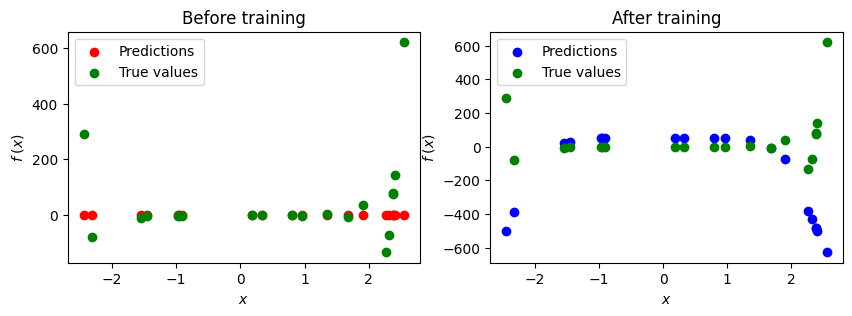

In [7]:
trained_state_dict = {k: v.detach().cpu().clone() for k, v in trainer.best_model.state_dict().items()}
trainer.best_model.load_state_dict(start_state_dict)
init_pred = trainer.predict(test_loader).squeeze().numpy()
trainer.best_model.load_state_dict(trained_state_dict)
predictions = trainer.predict(test_loader).squeeze().numpy()

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].scatter(test_x, init_pred, label="Predictions", color="red")
axs[0].scatter(test_x, test_y, label="True values", color="green")
axs[0].set_title("Before training")
axs[0].set_xlabel(r"$x$")
axs[0].set_ylabel(r"$f\;(x)$")
axs[0].legend()

axs[1].scatter(test_x, predictions, label="Predictions", color="blue")
axs[1].scatter(test_x, test_y, label="True values", color="green")
axs[1].set_title("After training")
axs[1].set_xlabel(r"$x$")
axs[1].set_ylabel(r"$f\;(x)$")
axs[1].legend()

plt.show()

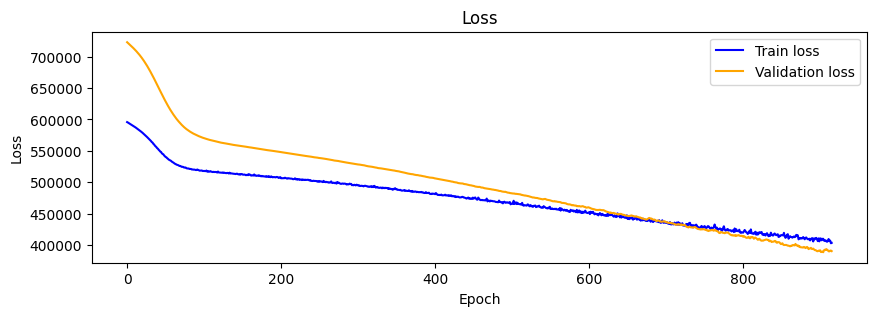

In [8]:
plt.figure(figsize=(10, 3))
plt.plot(trainer.train_loss, label="Train loss", color="blue")
plt.plot(trainer.val_loss, label="Validation loss", color="orange")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.show()

#### Зависимость синаптических коэффициентов сети $w(\tau)$ от времени обучения

- Нейронов скрытого слоя
- Выходного нейрона

*Powerwd by AI*

In [9]:
# Train a separate model and save weight dynamics w(t)
net_w = SLP(hidden_size).to(device)
criterion_w = nn.MSELoss()
optimizer_w = optim.SGD(net_w.parameters(), lr=learning_rate)

hidden_w_history = []  # shape: [epoch+1, hidden_size]
out_w_history = []     # shape: [epoch+1, hidden_size]

def snapshot_weights(model: nn.Module):
    with torch.no_grad():
        hidden_w = model.linear[0].weight.detach().cpu().numpy().reshape(-1)  # (hidden_size,)
        out_w = model.linear[2].weight.detach().cpu().numpy().reshape(-1)      # (hidden_size,)
    return hidden_w, out_w

# Save initial weights before training (t = 0)
h0, o0 = snapshot_weights(net_w)
hidden_w_history.append(h0)
out_w_history.append(o0)

for _ in range(epoch_amount):
    net_w.train()
    for batch_X, target in train_loader:
        optimizer_w.zero_grad()

        batch_X = batch_X.to(device)
        target = target.to(device)

        if batch_X.dim() == 1:
            batch_X = batch_X.unsqueeze(-1)
        if target.dim() == 1:
            target = target.unsqueeze(-1)

        pred = net_w(batch_X)
        target = target.to(dtype=pred.dtype)

        loss = criterion_w(pred, target)
        loss.backward()
        optimizer_w.step()

    h_t, o_t = snapshot_weights(net_w)
    hidden_w_history.append(h_t)
    out_w_history.append(o_t)

hidden_w_history = np.array(hidden_w_history)
out_w_history = np.array(out_w_history)
print(f"Hidden layer history shape: {hidden_w_history.shape}")
print(f"Output neuron history shape: {out_w_history.shape}")

Hidden layer history shape: (1001, 128)
Output neuron history shape: (1001, 128)


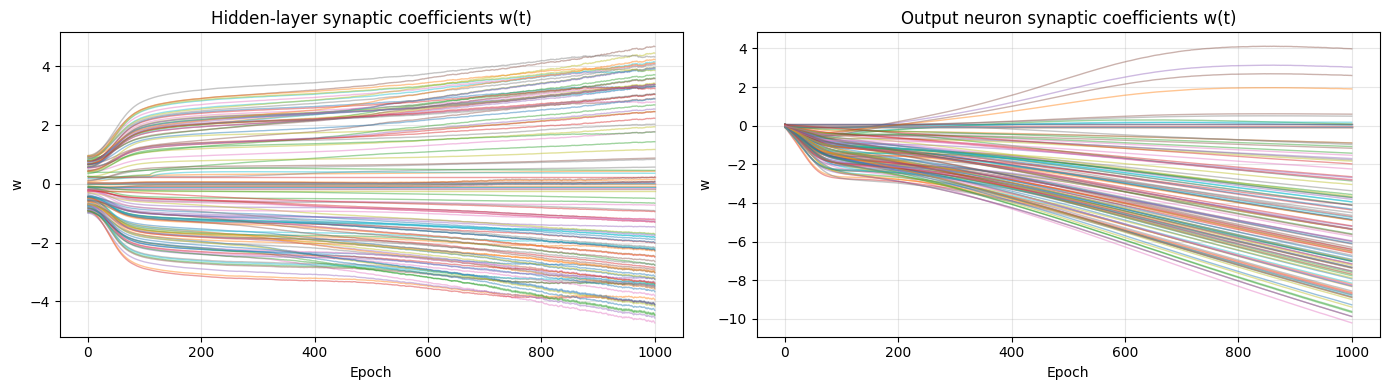

In [10]:
# Plot w(t) for hidden-layer neurons and output neuron
epochs_axis = np.arange(hidden_w_history.shape[0])

fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

for i in range(hidden_w_history.shape[1]):
    axs[0].plot(epochs_axis, hidden_w_history[:, i], alpha=0.45, linewidth=1)
axs[0].set_title("Hidden-layer synaptic coefficients w(t)")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("w")
axs[0].grid(True, alpha=0.3)

for i in range(out_w_history.shape[1]):
    axs[1].plot(epochs_axis, out_w_history[:, i], alpha=0.45, linewidth=1)
axs[1].set_title("Output neuron synaptic coefficients w(t)")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("w")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

def loss_creterian(net, criterion, loader):
    net.eval()
    total_loss = 0
    with torch.no_grad():
        for batch_X, target in loader:
            batch_X = batch_X.to(device)
            target = target.to(device)

            if batch_X.dim() == 1:
                batch_X = batch_X.unsqueeze(-1)
            if target.dim() == 1:
                target = target.unsqueeze(-1)
            
            pred = net(batch_X)
            loss = criterion(pred, target)
            total_loss += loss.item()
    return total_loss / len(loader)


class VolatilityLoss(nn.Module):
    def __init__(self, eps: float = 1e-8):
        super().__init__()
        self.eps = eps
    
    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)

        pred_std = torch.std(pred_flat, unbiased=False)
        target_std = torch.std(target_flat, unbiased=False)

        return torch.abs(pred_std - target_std) / (target_std + self.eps)


class RMSELoss(nn.Module):
    def __init__(self, eps: float = 1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        mse = torch.mean((pred - target) ** 2)
        return torch.sqrt(mse + self.eps)


loaders = [train_loader, val_loader, test_loader]
loader_names = ["train", "validation", "test"]

losses = [nn.L1Loss(), VolatilityLoss(), RMSELoss()]
loss_names = ["MAE", "Volatility", "RMSE"]

df_losses = pd.DataFrame(
    [[loss_creterian(trainer.best_model, loss_fn, loader) for loader in loaders] for loss_fn in losses],
    index=loss_names,
    columns=loader_names,
)

df_losses


,train,validation,test
MAE,316.363459,304.971954,265.464447
Volatility,0.590943,0.584303,0.620984
RMSE,602.727938,621.793803,421.895264


## Изменение нейросети

In [12]:
seed = 4
np.random.seed(seed)
torch.manual_seed(seed)

learning_rate = 1e-2
epoch_amount = 10000
hidden_size = 2048

class new_SLP(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.Sigmoid(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)

new_net = new_SLP(hidden_size)
new_optimizer = optim.Adam(new_net.parameters(), lr=learning_rate)

one_cycle_schedule = optim.lr_scheduler.OneCycleLR(
    new_optimizer,
    max_lr=learning_rate * 20,
    epochs=epoch_amount,
    steps_per_epoch=len(train_loader),
)

new_trainer = Trainer(
    new_net,
    criterion,
    new_optimizer,
    device,
    epoch_amount=epoch_amount,
    early_stopping=100,
    scheduler=lambda _: one_cycle_schedule,
)

new_trainer.fit(train_loader, val_loader)

Эпоха: 0 Loss_train: 589972.6809895834, 0:00:00.032497 сек
Loss_val: 705164.4583333334

Эпоха: 1 Loss_train: 579442.9361979166, 0:00:00.010000 сек
Loss_val: 691792.6875

Эпоха: 2 Loss_train: 573587.060546875, 0:00:00.006630 сек
Loss_val: 681035.5833333334

Эпоха: 3 Loss_train: 570093.6471354166, 0:00:00.006065 сек
Loss_val: 672608.6875

Эпоха: 4 Loss_train: 567735.4635416666, 0:00:00.006035 сек
Loss_val: 666442.9375

Эпоха: 5 Loss_train: 565106.58203125, 0:00:00.006141 сек
Loss_val: 663054.8125

Эпоха: 6 Loss_train: 564752.9765625, 0:00:00.005979 сек
Loss_val: 660828.4791666666

Эпоха: 7 Loss_train: 564815.7083333334, 0:00:00.005972 сек
Loss_val: 659236.4166666666

Эпоха: 8 Loss_train: 565047.21484375, 0:00:00.006073 сек
Loss_val: 658028.1041666666

Эпоха: 9 Loss_train: 564769.1875, 0:00:00.006105 сек
Loss_val: 657605.2916666666

Эпоха: 10 Loss_train: 564430.8697916666, 0:00:00.006212 сек
Loss_val: 657064.0

Эпоха: 11 Loss_train: 564040.8893229166, 0:00:00.006152 сек
Loss_val: 657021.5

In [13]:
new_df_losses = pd.DataFrame(
    [[loss_creterian(new_trainer.best_model, loss_fn, loader) for loader in loaders] for loss_fn in losses],
    index=loss_names,
    columns=loader_names,
)

new_df_losses

,train,validation,test
MAE,99.716925,93.109400,37.146667
Volatility,0.193519,0.114247,0.137012
RMSE,242.860992,226.991313,64.658295


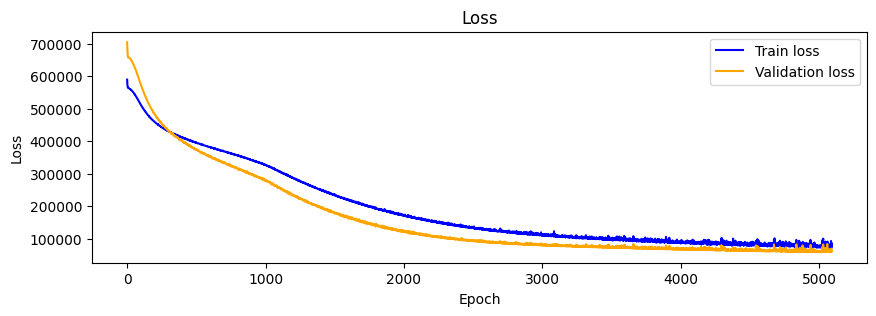

In [14]:
plt.figure(figsize=(10, 3))
plt.plot(new_trainer.train_loss, label="Train loss", color="blue")
plt.plot(new_trainer.val_loss, label="Validation loss", color="orange")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.show()

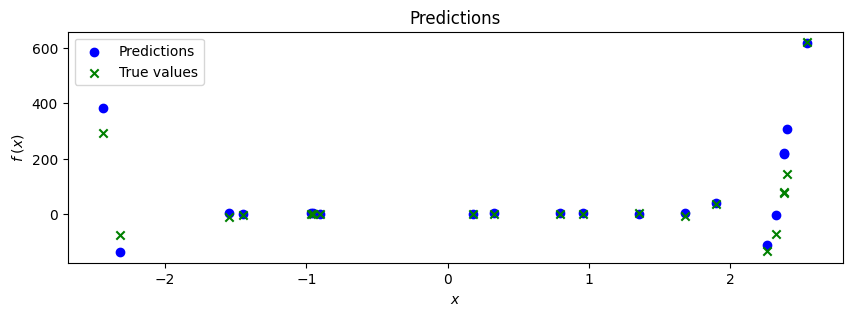

In [15]:
predictions = new_trainer.predict(test_loader).squeeze().numpy()

plt.figure(figsize=(10, 3))
plt.scatter(test_x, predictions, label="Predictions", marker="o", color="blue")
plt.scatter(test_x, test_y, label="True values", marker="x", color="green")
plt.title("Predictions")
plt.xlabel(r"$x$")
plt.ylabel(r"$f\;(x)$")
plt.legend()

plt.show()